In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#### BASIC GRAPH

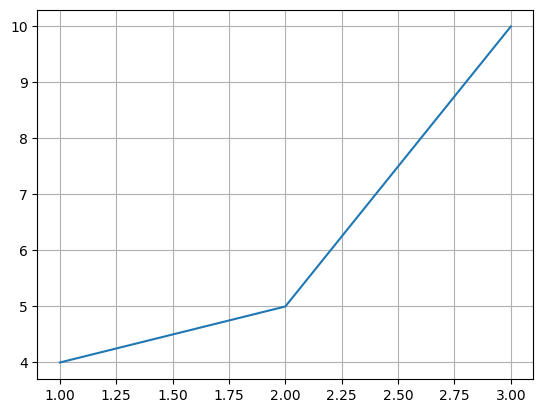

In [44]:
x = [1,2,3]
y = [4,5,10]
plt.plot(x,y)
plt.grid()
plt.show() # plotting point (1,4), (2,5), (3,10)

#### univariate - Numerical

In [10]:

df = pd.DataFrame({
    "age" : [18,19,18,25,20,21,30,23,24,21,31,19,27]
})

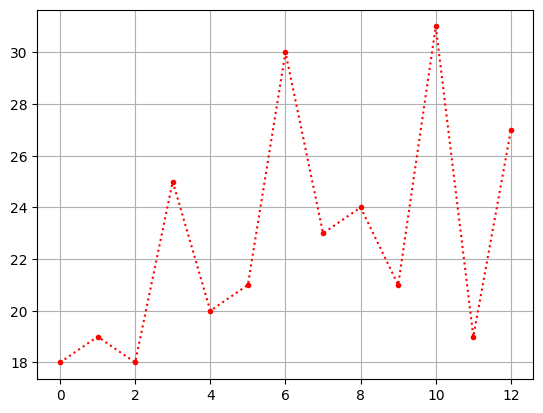

In [14]:
plt.plot(df["age"], color = "red", marker = ".", linestyle = ":") 
#linestyle = :, --
plt.grid()
plt.show()

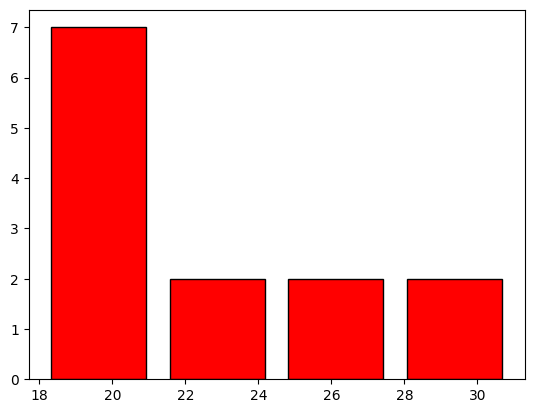

In [20]:
#histogram
plt.hist(df["age"], bins = 4, rwidth = 0.8, edgecolor = "black", color = "red")
plt.show()

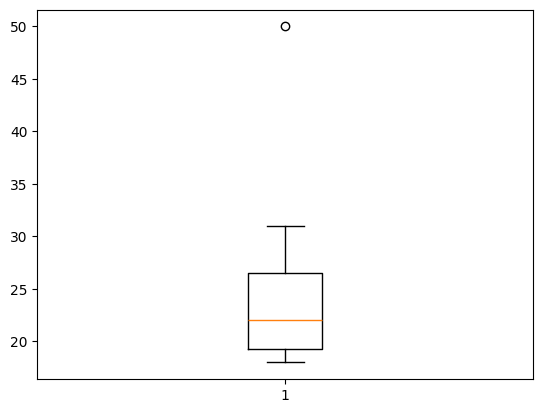

In [26]:
#box plot
plt.boxplot(df["age"])
plt.show()
df.loc[13] = 50

In [27]:
# dummy dataset
np.random.seed(42)
n = 80
df = pd.DataFrame({
    "score": np.random.randint(40, 100, n),
    "gender": np.random.choice(["Male", "Female"], n),
    "department": np.random.choice(["CSE", "ECE", "ME", "CE"], n)
})

In [28]:
df.head()

,score,gender,department
0,78,Female,CE
1,91,Female,CSE
2,68,Female,ME
3,54,Female,CE
4,82,Female,CE


In [30]:
genders = df["gender"].value_counts()
genders

gender
Female    43
Male      37
Name: count, dtype: int64

#### Univariate - Categorical

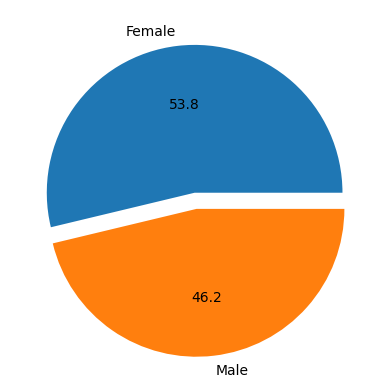

In [41]:
# pie Chart:
plt.pie(genders, labels = genders.index, autopct = "%1.1f", explode = [0.01, 0.1])
#explode : space between chart
#autopct : To show percentage
plt.show()

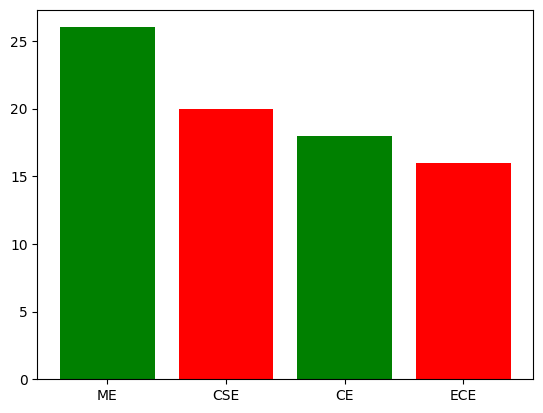

In [43]:
# bar / count plot
dept_count = df["department"].value_counts()
plt.bar(dept_count.index, dept_count, color = ["green", "red"])
plt.show()

#### bivariate: Numerical - numerical

In [46]:
df["age"] =  np.random.randint(18,25,n)
df.head()

,score,gender,department,age
0,78,Female,CE,20
1,91,Female,CSE,24
2,68,Female,ME,20
3,54,Female,CE,21
4,82,Female,CE,24


In [54]:
np.random.seed(42)

n = 100

study_hours = np.random.normal(5, 2, n).clip(0)
attendance = (study_hours * 10 + np.random.normal(50, 10, n)).clip(0, 100)
marks = (study_hours * 8 + attendance * 0.3 + np.random.normal(0, 5, n)).clip(0, 100)
gender = np.random.choice(["Male", "Female"], n)

department = np.where(marks > 75, "CSE",
              np.where(marks > 60, "ECE",
              np.where(marks > 50, "ME", "CE")))

performance = np.where(marks > 80, "Excellent",
               np.where(marks > 65, "Good",
               np.where(marks > 50, "Average", "Poor")))

df2 = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "marks": marks,
    "gender": gender,
    "department": department,
    "performance": performance
})
df2 = df2.sort_values(by="marks").reset_index(drop = True)
print(df2.head())

   study_hours  attendance      marks  gender department performance
0     0.000000   52.766908  10.922529  Female         CE        Poor
1     2.150504   57.486526  26.386407    Male         CE        Poor
2     1.080660   57.585982  26.853344    Male         CE        Poor
3     1.550164   63.578034  29.898379    Male         CE        Poor
4     2.042956   73.028388  32.250683    Male         CE        Poor


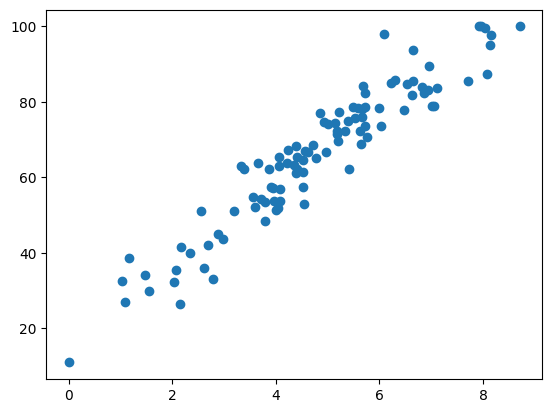

In [55]:
# scatter plot 
plt.scatter(df2["study_hours"], df2["marks"])
plt.show()

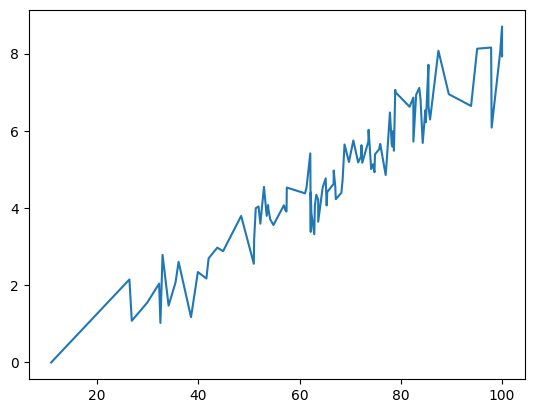

In [57]:
#line plot
plt.plot(df2["marks"], df2["study_hours"])
plt.show()

<BarContainer object of 100 artists>

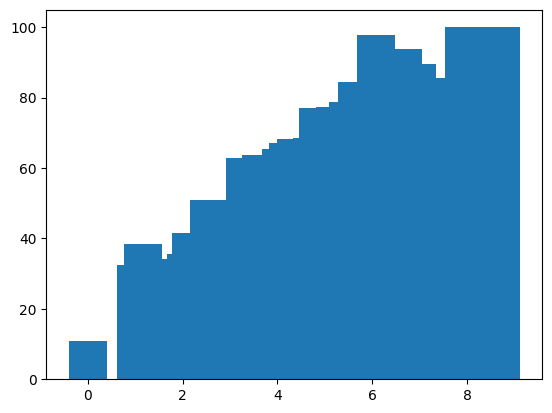

In [61]:
#bar chart
plt.bar(df2["study_hours"], df2["marks"], align="center")

#### bivarivate: Categorical - Numerical

<BarContainer object of 4 artists>

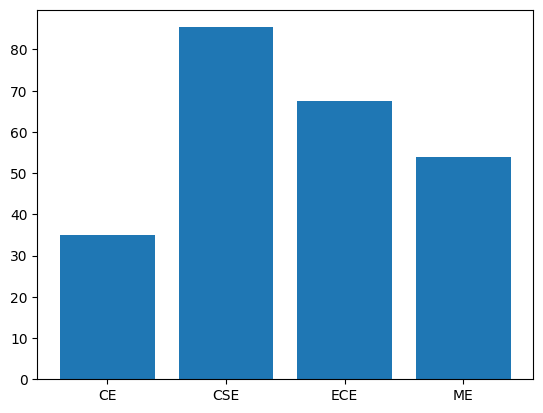

In [76]:
dept_mean = df2.groupby("department")[["marks"]].mean()
type(dept_mean)
plt.bar(dept_mean.index,dept_mean["marks"])

#### Multivariate Analysis: 3 numerical columns

In [78]:
df2.head()

,study_hours,attendance,marks,gender,department,performance
0,0.000000,52.766908,10.922529,Female,CE,Poor
1,2.150504,57.486526,26.386407,Male,CE,Poor
2,1.080660,57.585982,26.853344,Male,CE,Poor
3,1.550164,63.578034,29.898379,Male,CE,Poor
4,2.042956,73.028388,32.250683,Male,CE,Poor


In [80]:
# correlation
df2[["study_hours", "attendance", "marks"]].corr()

,study_hours,attendance,marks
study_hours,1.000000,0.760257,0.950721
attendance,0.760257,1.000000,0.814172
marks,0.950721,0.814172,1.000000


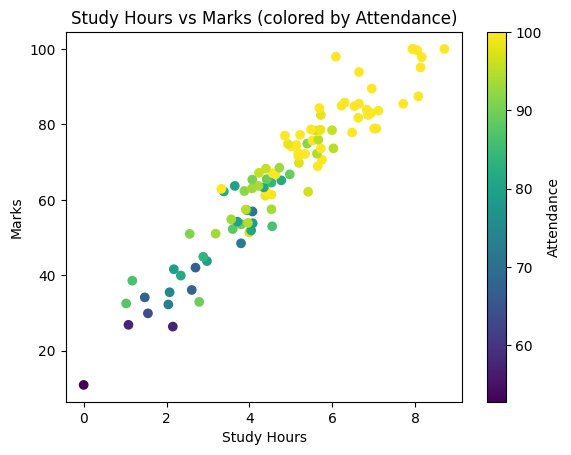

In [84]:
plt.scatter(df2["study_hours"], df2["marks"], c=df2["attendance"])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.colorbar(label="Attendance")
plt.title("Study Hours vs Marks (colored by Attendance)")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

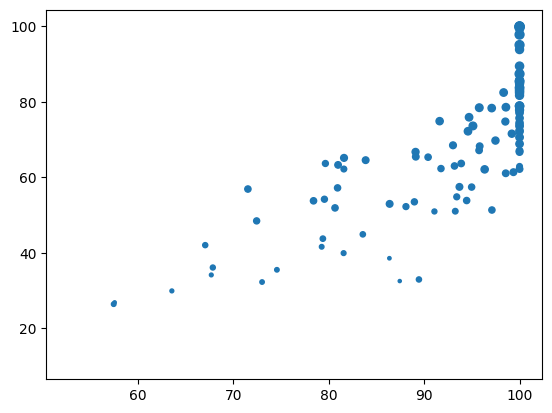

In [88]:
plt.scatter(df2["attendance"], df2["marks"], s=df2["study_hours"]*5)
plt.show

In [89]:
np.random.seed(42)

years = np.arange(2018, 2025)
companies = ["Alpha", "Beta", "Gamma", "Delta"]
regions = ["North", "South", "East", "West"]

data = []

for company in companies:
    base = np.random.uniform(200, 500)
    
    for year in years:
        growth = (year - 2018) * np.random.uniform(15, 40)
        
        for region in regions:
            seasonal = np.random.normal(0, 20)
            
            sales = base + growth + seasonal
            profit = sales * np.random.uniform(0.1, 0.25)
            
            data.append([company, year, region, sales, profit])

df3 = pd.DataFrame(data, columns=["company", "year", "region", "sales", "profit"])

print(df3.head())

  company  year region       sales     profit
0   Alpha  2018  North  325.315806  40.144880
1   Alpha  2018  South  342.822633  42.304031
2   Alpha  2018   East  343.946292  35.456623
3   Alpha  2018   West  327.710730  80.448553
4   Alpha  2019  North  336.555539  42.914424


In [90]:
df3.sample(10)

,company,year,region,sales,profit
95,Delta,2020,West,440.385678,105.361298
99,Delta,2021,West,461.744374,111.014068
6,Alpha,2019,East,295.922121,42.519384
91,Delta,2019,West,431.500440,61.323054
87,Delta,2018,West,378.573664,60.179833
49,Beta,2023,South,519.451123,115.682916
34,Beta,2019,East,464.756628,85.604258
71,Gamma,2021,West,457.117318,101.746695
107,Delta,2023,West,562.160987,99.334611
56,Gamma,2018,North,350.379156,37.743478


In [91]:
df3 = df3.sort_values(by="year").reset_index(drop= True)

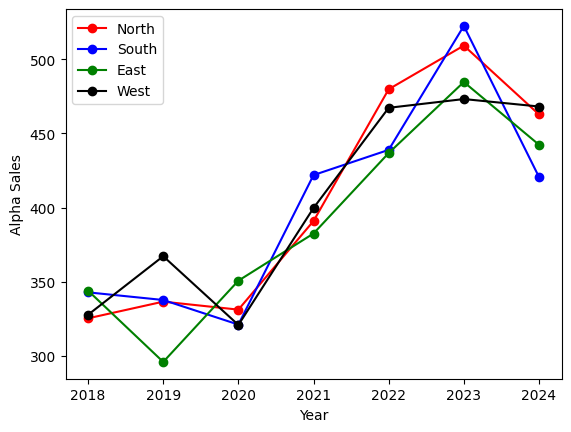

In [118]:
plt.plot(df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "North"), "year"],
         df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "North"), "sales"],
         marker="o", color="red", label="North")

plt.plot(df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "South"), "year"],
         df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "South"), "sales"],
         marker="o", color="blue", label="South")

plt.plot(df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "East"), "year"],
         df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "East"), "sales"],
         marker="o", color="green", label="East")

plt.plot(df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "West"), "year"],
         df3.loc[(df3["company"] == "Alpha") & (df3["region"] == "West"), "sales"],
         marker="o", color="black", label="West")

plt.xlabel("Year")
plt.ylabel("Alpha Sales")
plt.legend()
plt.show()

In [101]:
df3

,company,year,region,sales,profit
0,Alpha,2018,North,325.315806,40.144880
1,Alpha,2018,South,342.822633,42.304031
2,Alpha,2018,East,343.946292,35.456623
3,Alpha,2018,West,327.710730,80.448553
4,Beta,2018,West,408.344024,60.752402
...,...,...,...,...,...
107,Gamma,2024,North,576.015307,113.932481
108,Delta,2024,North,571.535124,117.333321
109,Delta,2024,South,582.828627,127.854475
110,Delta,2024,East,553.811929,86.581541


### Object Oriented API

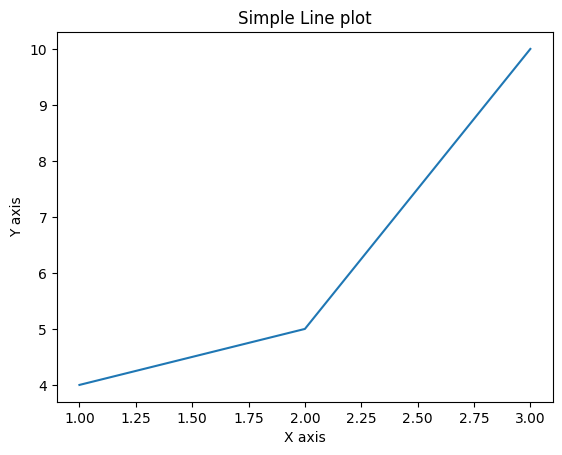

In [119]:
fig,ax = plt.subplots()
ax.plot(x,y)
ax.set_title("Simple Line plot")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
plt.show()

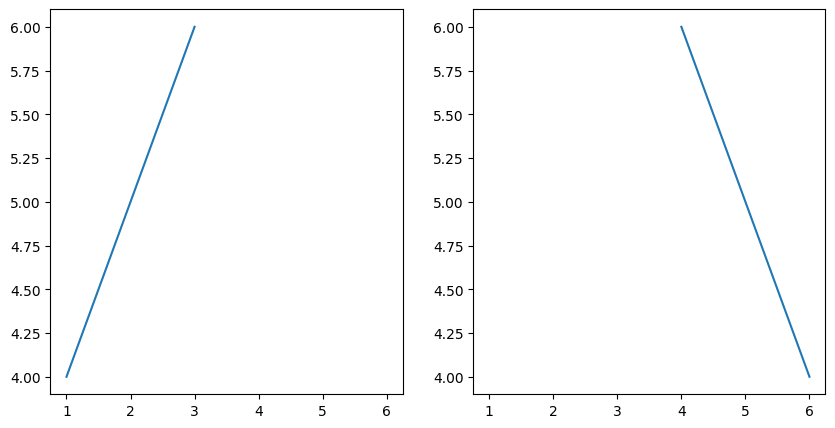

In [127]:
fig, ax = plt.subplots(1, 2, figsize = (10,5), sharex=True)

ax[0].plot([1,2,3], [4,5,6])
ax[1].plot([4,5,6], [6,5,4])

plt.show()

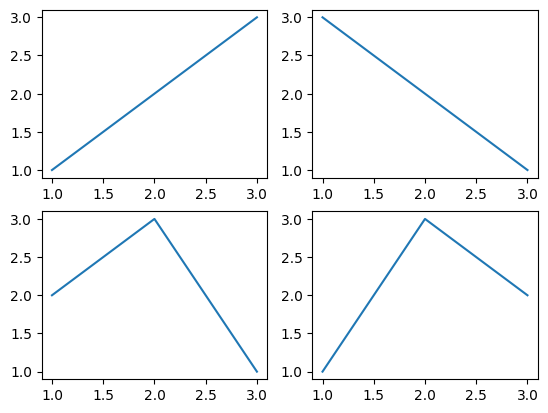

In [128]:
fig, ax = plt.subplots(2, 2)

ax[0,0].plot([1,2,3], [1,2,3])
ax[0,1].plot([1,2,3], [3,2,1])
ax[1,0].plot([1,2,3], [2,3,1])
ax[1,1].plot([1,2,3], [1,3,2])